## <font color='orange'>Import libraries</font>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import os
import cv2
import random
import glob as gb
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Convolution2D, MaxPooling2D, Flatten, Dense,Dropout,Conv2D
from tensorflow.keras.utils import plot_model

d:\education\BFCAI 3rd\2nd Term\Neural Network\Sections\Coding\envs\neural\lib\site-packages\tensorflow\python\framework\dtypes.py:523: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
d:\education\BFCAI 3rd\2nd Term\Neural Network\Sections\Coding\envs\neural\lib\site-packages\tensorflow\python\framework\dtypes.py:524: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
d:\education\BFCAI 3rd\2nd Term\Neural Network\Sections\Coding\envs\neural\lib\site-packages\tensorflow\python\framework\dtypes.py:525: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_q

## <font color='orange'>This function to load data from paths</font>

In [24]:
img_size = 150
binary_classifciation= {'benign': 0, 'malignant': 1}

def loading_data(path):
    _images = []
    _labels = []
    
    for folder in os.listdir(path): #benign, malignant
        folder_path = os.path.join(path, folder) # melanoma_cancer_dataset/train/benign #### melanoma_cancer_dataset/train/malignant
        data = gb.glob(pathname=str(folder_path + '/*.jpg')) #use glob to get all images with exitnation jpg
        
        if(folder=='benign'):
            print(f'benign: {len(data)}')
        else:
            print(f'malignant: {len(data)}')
            
        for img_path in tqdm(data):
            img = cv2.imread(img_path) # read image and return numpy array
            img = cv2.resize(img, (img_size, img_size))
            _images.append(img)
            _labels.append(binary_classifciation[folder])
    return _images,_labels

## <font color='orange'>Get training data </font>

In [25]:
#train_data = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train'

train_data = "D:\\education\\BFCAI 3rd\\2nd Term\\Neural Network\\Project\\melanoma_cancer_dataset\\train\\"
train_images,train_labels = loading_data(train_data)

benign: 4900


100%|██████████| 4900/4900 [00:13<00:00, 367.56it/s]


malignant: 4505


100%|██████████| 4505/4505 [00:09<00:00, 477.93it/s]


## <font color='orange'>Get testing data</font>

In [26]:
#test_data = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test'

test_data = "D:\\education\\BFCAI 3rd\\2nd Term\\Neural Network\\Project\\melanoma_cancer_dataset\\test\\"
test_images,test_labels = loading_data(test_data)

benign: 500


100%|██████████| 500/500 [00:02<00:00, 176.79it/s]


malignant: 500


100%|██████████| 500/500 [00:02<00:00, 188.66it/s]


## <font color='orange'>Get validation data</font>

In [27]:
validation_data = "D:\\education\\BFCAI 3rd\\2nd Term\\Neural Network\\Project\\melanoma_cancer_dataset\\validation\\"
validation_images,validation_labels = loading_data(validation_data)

benign: 100


100%|██████████| 100/100 [00:00<00:00, 143.72it/s]


malignant: 100


100%|██████████| 100/100 [00:00<00:00, 213.64it/s]


## <font color='orange'>Get Predicted data</font>

In [28]:
pred_data = "D:\\education\\BFCAI 3rd\\2nd Term\\Neural Network\\Project\\melanoma_cancer_dataset\\predict\\"
pred_images = []

for folder in os.listdir(pred_data): #benign, malignant
    folder_path = os.path.join(pred_data, folder) # melanoma_cancer_dataset/predict/benign #### melanoma_cancer_dataset/predict/malignant
    data = gb.glob(pathname=str(folder_path + '/*.jpg')) #use glob to get all images with exitnation jpg
    if(folder=='benign'):
        print(f'benign: {len(data)}')
    else:
        print(f'malignant: {len(data)}')
    for img_path in tqdm(data):
        img = cv2.imread(img_path) # read image and return numpy array
        img = cv2.resize(img, (img_size, img_size))
        pred_images.append(img)

benign: 500


100%|██████████| 500/500 [00:03<00:00, 135.78it/s]


malignant: 500


100%|██████████| 500/500 [00:03<00:00, 156.64it/s]


## <font color='orange'>Size of train benign images</font>

In [29]:
size = []
files = gb.glob(pathname= str( train_data +'//benign' + '/*.jpg'))
for file in tqdm(files): 
    image = plt.imread(file)
    size.append(image.shape)

#count each similar size contained in size list to know most common size in images        
pd.Series(size).value_counts()

100%|██████████| 4900/4900 [00:08<00:00, 586.31it/s]


(300, 300, 3)    4900
dtype: int64

## <font color='orange'>Size of train malignant images</font>

In [30]:
size = []
files = gb.glob(pathname= str( train_data +'//malignant' + '/*.jpg'))
for file in tqdm(files): 
    image = plt.imread(file)
    size.append(image.shape)

#count each similar size contained in size list to know most common size in images        
pd.Series(size).value_counts()

100%|██████████| 4505/4505 [00:07<00:00, 624.75it/s]


(300, 300, 3)    4505
dtype: int64

## <font color='orange'>This function to gel label(class) of image</font>

In [31]:
def get_label(n) : 
    for key,value in binary_classifciation.items() : 
        if n == value : 
            return key

## <font color='orange'>This function to show number of images from dataset</font>

In [32]:
def Show_images(images,labels):
    random_indexs = random.sample(range(len(images)), 25)#0 => length of train images  25 random numbers in this case 0 => 9605
    print(random_indexs)
    plt.figure(figsize=(15, 15))
    for n in range(25):
        i = random_indexs[n]
        plt.subplot(5, 5, n+1)
        plt.imshow(images[i])
        plt.axis('off')
        label=get_label(labels[i])
        plt.title(label) #Print label of image in top
    plt.show()

### <font color='orange'>Show 25 image for training data</font>

[5120, 7260, 1562, 2758, 4463, 7930, 6696, 7781, 7586, 3424, 6982, 8038, 1659, 3584, 5102, 7153, 8356, 2804, 2669, 714, 2541, 4764, 2752, 7301, 624]


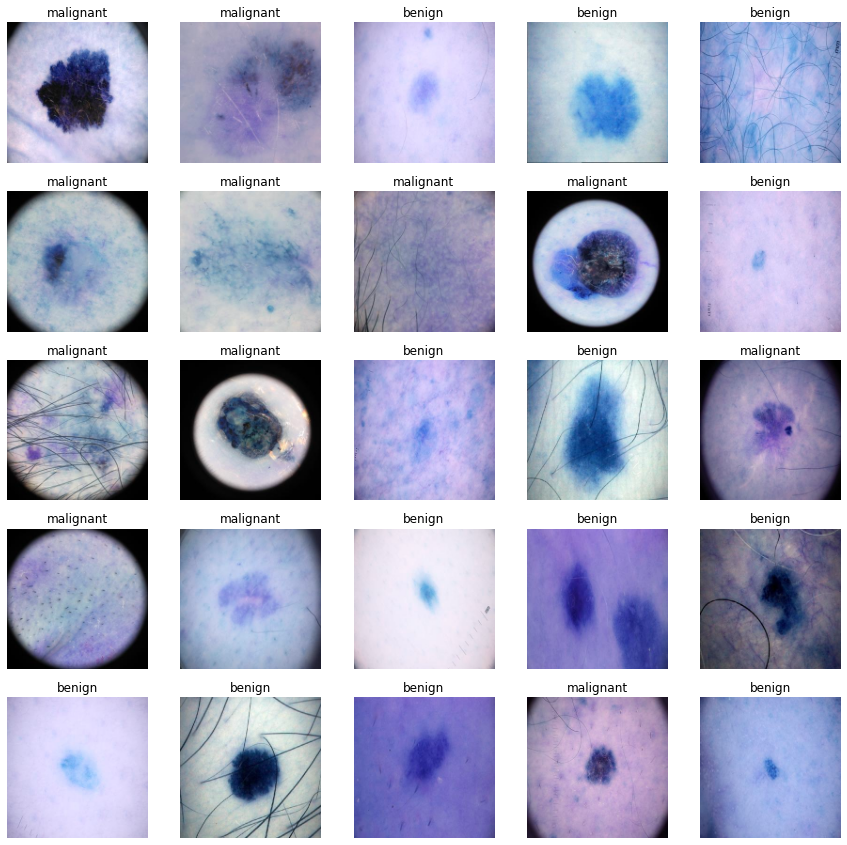

In [33]:
Show_images(train_images,train_labels)

### <font color='orange'>Show 25 image for testing data</font>

[490, 133, 702, 229, 219, 6, 157, 256, 882, 547, 933, 206, 870, 43, 666, 864, 715, 792, 170, 435, 580, 484, 453, 121, 923]


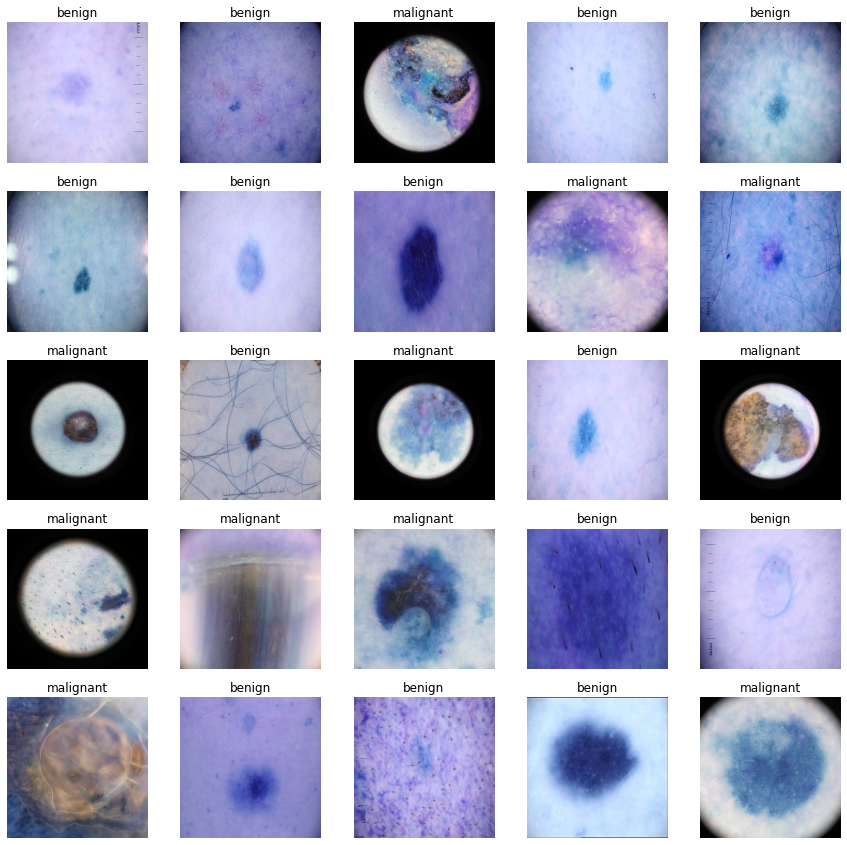

In [34]:
Show_images(test_images,test_labels)

### <font color='orange'>Convert lists to nparrays and show there shapes</font>

In [35]:
train_images = np.asarray(train_images)
test_images = np.asarray(test_images)
validation_images = np.asarray(validation_images)
pred_images = np.asarray(pred_images)

train_labels = np.asarray(train_labels)
test_labels = np.asarray(test_labels)
validation_labels = np.asarray(validation_labels)

print("Train image Shape: ",train_images.shape)
print("Test image Shape: ",test_images.shape)
print("Validation image Shape: ",validation_images.shape)
print("Predict image Shape: ",pred_images.shape)
print("---------------------------------------------")
print("Train label Shape: ",train_labels.shape)
print("Test label Shape: ",test_labels.shape)
print("Validation label Shape: ",validation_labels.shape)

Train image Shape:  (9405, 150, 150, 3)
Test image Shape:  (1000, 150, 150, 3)
Validation image Shape:  (200, 150, 150, 3)
Predict image Shape:  (1000, 150, 150, 3)
---------------------------------------------
Train label Shape:  (9405,)
Test label Shape:  (1000,)
Validation label Shape:  (200,)


### <font color='orange'>Normalize values</font>

In [36]:
train_images = train_images/255.0
test_images = test_images/255.0
#print(train_images[0])

In [37]:
validaton_images = validation_images/255.0
pred_images = pred_images/255.0

## <font color='orange'>Model Creation</font>

In [44]:
def create_model():
    model = Sequential([
        Convolution2D(64, 3, 3, activation='relu',input_shape=(img_size,img_size,3)),
        MaxPooling2D(pool_size=(2, 2)),
        Convolution2D(64, 3, 3, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer ='adam',loss='binary_crossentropy',metrics=['accuracy'])
    return model

In [45]:
model = create_model()

In [53]:
checkpoint_path = 'skin_cancer_detector.h5'

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 save_best_only=True,
                                                 monitor='loss',
                                                 mode='min',
                                                 verbose=1)

history = model.fit(train_images, train_labels, epochs=2,batch_size=1,callbacks=[cp_callback],validation_data=(validaton_images,validation_labels))

Train on 9405 samples, validate on 200 samples
Epoch 1/2
9405/9405 [==============================] - 41s 4ms/step - loss: 0.2364 - acc: 0.9015 - val_loss: 0.2355 - val_acc: 0.9150

Epoch 00001: loss improved from inf to 0.23637, saving model to skin_cancer_detector.h5
Epoch 2/2
9405/9405 [==============================] - 41s 4ms/step - loss: 0.2315 - acc: 0.9057 - val_loss: 0.2717 - val_acc: 0.8700

Epoch 00002: loss improved from 0.23637 to 0.23152, saving model to skin_cancer_detector.h5


In [54]:
val_loss, val_acc = model.evaluate(test_images, test_labels)
print(val_loss)
print(val_acc)

1000/1000 [==============================] - 4s 4ms/step
0.22844059439748526
0.901


In [55]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 50, 50, 64)        1792      
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 25, 25, 64)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 8, 8, 64)          36928     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 4, 4, 64)          0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 1024)              0         
_________________________________________________________________
dense_6 (Dense)              (None, 128)               131200    
_________________________________________________________________
dropout_3 (Dropout)          (None, 128)               0         
__________

## <font color='orange'>Create new model to load data</font>

In [56]:
new_model = create_model()

## <font color='orange'>evalute new model before loading weights</font>

In [57]:
val_loss, val_acc = new_model.evaluate(test_images, test_labels)
print(val_loss)
print(val_acc)

1000/1000 [==============================] - 3s 3ms/step
0.7115528573989868
0.5


## <font color='orange'>evalute new model after loading weights</font>

In [58]:
# Load weights of old model
new_model.load_weights(checkpoint_path)
val_loss, val_acc = new_model.evaluate(test_images, test_labels)
print(val_loss)
print(val_acc)

1000/1000 [==============================] - 1s 1ms/step
0.22844059439748526
0.901


In [59]:
new_model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_8 (Conv2D)            (None, 50, 50, 64)        1792      
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 25, 25, 64)        0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 8, 8, 64)          36928     
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 4, 4, 64)          0         
_________________________________________________________________
flatten_4 (Flatten)          (None, 1024)              0         
_________________________________________________________________
dense_8 (Dense)              (None, 128)               131200    
_________________________________________________________________
dropout_4 (Dropout)          (None, 128)               0         
__________

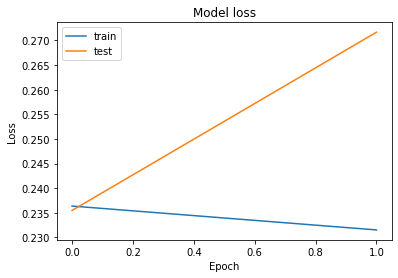

In [60]:
# Plot loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


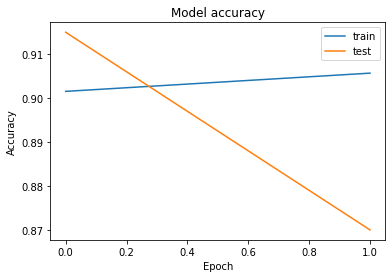

In [61]:
# Plot accuracy
plt.plot(history.history['acc'], label='train')
plt.plot(history.history['val_acc'], label='test')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## <font color='orange'>Predicted data</font>

In [62]:
y_labels=model.predict(test_images)
print('Predicted data Shape: ',y_labels.shape)
y_labels = np.round(y_labels)

Predicted data Shape:  (1000, 1)


In [63]:
pred_labels=model.predict(pred_images)
print('Predicted data Shape: ',pred_labels.shape)
pred_labels = np.round(pred_labels)

Predicted data Shape:  (1000, 1)


### <font color='orange'>Show 25 image for predicting data</font>

[738, 53, 375, 500, 822, 417, 393, 192, 627, 109, 299, 719, 314, 453, 29, 98, 203, 835, 454, 244, 679, 424, 950, 898, 274]


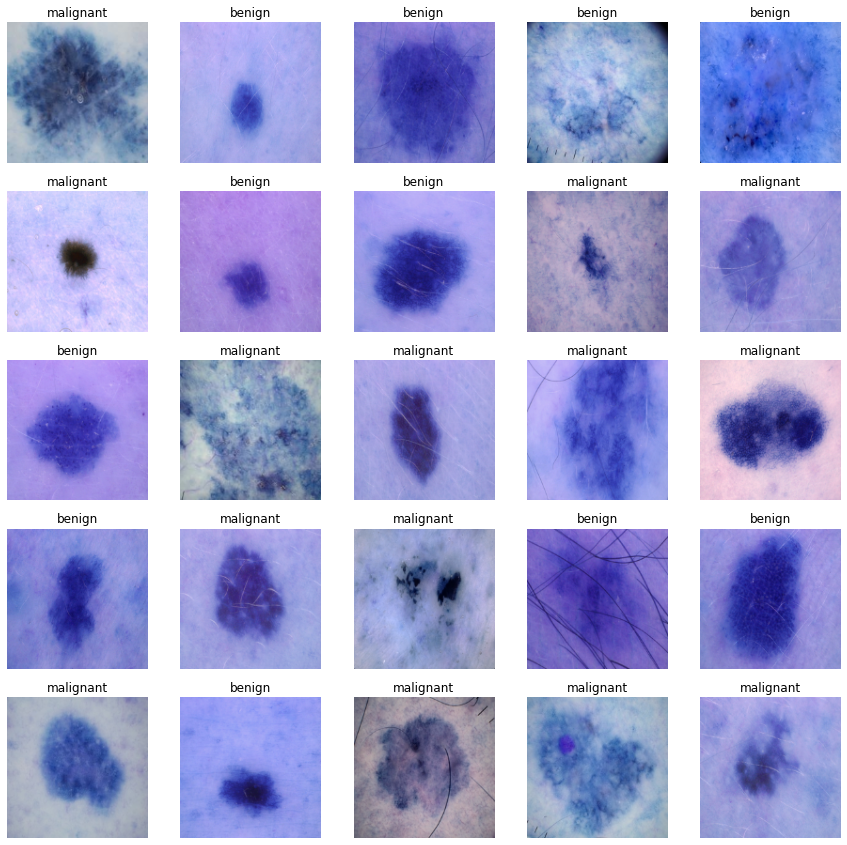

In [37]:
Show_images(pred_images,pred_labels)

### <font color='orange'>Chart to compare between Test and Predict labels</font>

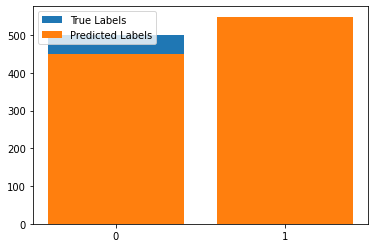

In [64]:

# Get the counts of each class in the test data and the predicted data
unique, counts_test = np.unique(test_labels, return_counts=True) # unqiue of class [0,1] count_test = number of images in one class
unique, counts_pred = np.unique(pred_labels, return_counts=True) # unqiue of class [0,1] count_predict = number of images in one class

# Create a bar chart
fig, ax = plt.subplots()
ax.bar(unique, counts_test, label='True Labels')
ax.bar(unique, counts_pred, label='Predicted Labels')
ax.set_xticks(unique)
ax.legend()
plt.show()

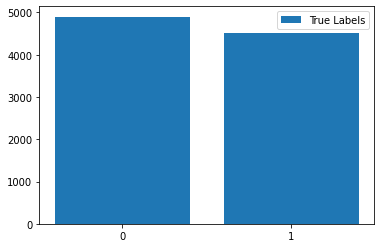

In [65]:
unqiue, count_train = np.unique(train_labels,return_counts=True) # unqiue of class [0,1] count_train = number of images in one class
fig,ax = plt.subplots()
ax.bar(unique,count_train,label='True Labels')
ax.set_xticks(unqiue)
ax.legend()
plt.show()

In [66]:
from sklearn.metrics import classification_report
print(classification_report(test_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.70      0.63      0.66       500
           1       0.66      0.73      0.69       500

    accuracy                           0.68      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.68      0.68      0.68      1000



In [67]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(test_labels, pred_labels))

[[315 185]
 [136 364]]


In [ ]:
# Need different verison
#plot_model(model, to_file='model_nn.png',show_shapes=True)